In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# All auxiliary code is in ../src
import sys
sys.path.append("../../src/")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from distribution_utility import show_heatmap
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
import seaborn as sbn
from scipy.stats import ks_2samp

In [4]:
races=pd.read_csv('../../dataset/preprocessedRaces_without_outliers.csv', sep=",")
placements=pd.read_csv('../../dataset/preprocessedPlacements.csv', sep=",")
cyclists=pd.read_csv('../../dataset/preprocessedCyclists_without_outliers.csv', sep=",")

We decided to use the dataset without outliers for classification. In fact, there are some classifiers that are based on the notion of distance, so the presence of outliers will negatively affect their performance. Clearly, we are removing some rows from the original dataset, but we expect this loss to improve the quality of the classifier.

In [5]:
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)

## Feature selection

Reconstruction of the original dataset by merging the three dataset produced for the previous tasks. We do not include in the final dataset those columns excluded from the analysis due not resolved data quality issues or because of redundancy. 

In [6]:
cyclists.drop(['AVG weighted position', 'AVG position Autumn', 'AVG position Spring', 'AVG position Summer', 'AVG position Winter', 'AVG position Q1', 'AVG position Q2', 'AVG position Q3', 'AVG position Q4'], axis=1, inplace=True)
cyclists.columns

Index(['name', 'BMI', 'median position', 'AVG position', '# cyclist races',
       'nationality', 'continent', 'geo area', 'birth_year',
       'std_dev position'],
      dtype='object')

In [7]:
races.drop(['uci_points', 'average_temperature', 'is_tarmac', 'is_cobbled', 'is_gravel'], axis=1, inplace=True)
races.columns

Index(['_url', 'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [8]:
placements.drop(['cyclist_team'], axis=1, inplace=True)
placements.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date', '_url', 'year'], dtype='object')

In [9]:
placements.head()

,position,cyclist,cyclist_age,delta,date,_url,year
0,0,georges-pintens,24,0,1970-04-25,amstel-gold-race/1970/result,1970
1,1,willy-van-neste,26,0,1970-04-25,amstel-gold-race/1970/result,1970
2,2,andre-dierickx,23,22,1970-04-25,amstel-gold-race/1970/result,1970
3,3,eric-leman,24,33,1970-04-25,amstel-gold-race/1970/result,1970
4,4,joseph-schoeters,23,33,1970-04-25,amstel-gold-race/1970/result,1970


In [10]:
races.head()

,_url,name,points,length,climb_total,profile,startlist_quality,date,climb/length,median_delta,std_delta
0,tour-de-france/1978/stage-6,Tour de France,100,162000,1101,1,1241,1978-07-05,0.006796,27.0,6.847590
1,vuelta-a-espana/2016/stage-14,Vuelta a España,80,196000,5575,5,821,2016-09-03,0.028444,1957.0,873.835670
2,tour-de-france/2019/stage-21,Tour de France,100,128000,781,1,1699,2019-07-28,0.006102,29.0,44.079531
3,volta-a-catalunya/1999/prologue,Volta Ciclista a Catalunya,50,8100,68,1,804,1999-06-17,0.008395,53.0,27.154498
4,tour-de-france/2022/stage-9,Tour de France,100,192900,3743,3,1551,2022-07-10,0.019404,1376.0,675.354230


In [11]:
cyclists.head()

,name,BMI,median position,AVG position,# cyclist races,nationality,continent,geo area,birth_year,std_dev position
0,gerrie-knetemann,19.959003,38,48,271,Netherlands,Europe,Western Europe,1951.0,46.993017
1,rene-bittinger,22.790000,42,47,146,France,Europe,Western Europe,1954.0,32.648452
2,joseph-bruyere,23.086015,8,16,48,Belgium,Europe,Western Europe,1948.0,19.723611
3,sven-ake-nilsson,21.300000,25,33,145,Sweden,Europe,Northern Europe,1951.0,26.276978
4,jacques-esclassan,20.916803,7,29,62,France,Europe,Western Europe,1948.0,34.928320


Reconstruction of the original dataset including the new features.

In [12]:
dataset=pd.merge(placements, races, how='inner', on='_url')
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', 'date_x', '_url', 'year',
       'name', 'points', 'length', 'climb_total', 'profile',
       'startlist_quality', 'date_y', 'climb/length', 'median_delta',
       'std_delta'],
      dtype='object')

In [13]:
dataset.drop(['date_y', 'date_x'], axis=1, inplace=True)

In [14]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'name',
       'points', 'length', 'climb_total', 'profile', 'startlist_quality',
       'climb/length', 'median_delta', 'std_delta'],
      dtype='object')

In [15]:
dataset=pd.merge(dataset, cyclists, how='inner', left_on='cyclist', right_on='name')

In [16]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'name_x',
       'points', 'length', 'climb_total', 'profile', 'startlist_quality',
       'climb/length', 'median_delta', 'std_delta', 'name_y', 'BMI',
       'median position', 'AVG position', '# cyclist races', 'nationality',
       'continent', 'geo area', 'birth_year', 'std_dev position'],
      dtype='object')

In [17]:
dataset.drop(['name_x', 'name_y'], axis=1, inplace=True)

In [18]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'points',
       'length', 'climb_total', 'profile', 'startlist_quality', 'climb/length',
       'median_delta', 'std_delta', 'BMI', 'median position', 'AVG position',
       '# cyclist races', 'nationality', 'continent', 'geo area', 'birth_year',
       'std_dev position'],
      dtype='object')

Actually we will use our model to predict the future placements (>=2022) of the cylists, for this reason we need to adjust some statistics of the cyclists which are calculated on the whole dataset, hence considering all the placements which are in the range (1970-2023). Moreover we need to exclude those columns that, in some sense, immediately allow us to assing the proper label (such as the _'position'_ but also the _'delta'_).

### Redefinition of the cyclist statistics

In [19]:
new_stats=pd.merge(placements, cyclists, left_on='cyclist', right_on='name', how='inner')

In [20]:
print(f"# of placements: {new_stats.shape[0]}")
print(f"# of placements >=2022: {new_stats[new_stats['year']>=2022].shape[0]}")

# of placements: 511694
# of placements >=2022: 32586


In [21]:
new_stats=new_stats[['cyclist','position', 'year']]
new_stats=new_stats[new_stats['year']<2022]
new_stats

,cyclist,position,year
0,georges-pintens,0,1970
1,willy-van-neste,1,1970
2,andre-dierickx,2,1970
3,eric-leman,3,1970
4,joseph-schoeters,4,1970
...,...,...,...
511592,johan-esteban-chaves,63,2021
511593,nelson-soto,64,2021
511594,pascal-eenkhoorn,65,2021
511595,nikias-arndt,66,2021


In [22]:
print(f"# of cyclists with placements <2022:{new_stats['cyclist'].unique().shape[0]}")

# of cyclists with placements <2022:5648


In [23]:
new_stats['median position'] = new_stats.groupby('cyclist')['position'].transform(lambda x: round(x.median()))
new_stats['AVG position'] = new_stats.groupby('cyclist')['position'].transform(lambda x: round(x.mean()))
new_stats['# cyclist races'] = new_stats.groupby('cyclist')['cyclist'].transform("count")

#We had to define this custom function because the default one did not work.
def custom_std(x):
    return x.std() if len(x) > 1 else 0
new_stats['std_dev position'] = new_stats.groupby('cyclist')['position'].transform(custom_std)

In [24]:
print(new_stats.dtypes)
print(new_stats.isna().sum())

cyclist              object
position              int64
year                  int64
median position       int64
AVG position          int64
# cyclist races       int64
std_dev position    float64
dtype: object
cyclist             0
position            0
year                0
median position     0
AVG position        0
# cyclist races     0
std_dev position    0
dtype: int64


In [25]:
new_stats

,cyclist,position,year,median position,AVG position,# cyclist races,std_dev position
0,georges-pintens,0,1970,4,13,37,18.685480
1,willy-van-neste,1,1970,6,10,10,8.141116
2,andre-dierickx,2,1970,8,16,67,18.234961
3,eric-leman,3,1970,4,7,38,7.836705
4,joseph-schoeters,4,1970,19,20,7,9.860938
...,...,...,...,...,...,...,...
511592,johan-esteban-chaves,63,2021,33,45,373,37.031503
511593,nelson-soto,64,2021,140,118,33,47.450053
511594,pascal-eenkhoorn,65,2021,76,76,37,32.762477
511595,nikias-arndt,66,2021,88,88,343,50.876602


In [26]:
new_stats.drop(['position', 'year'], axis=1, inplace=True)
new_stats.drop_duplicates(inplace=True)
new_stats.shape[0]

5648

We note that we have 5648 cyclists with information about their races. This is less than the original number of cyclists because some of them have only participated in races after 2022 (included). We delete the columns with the overall statistics and we add the new statistics.

In [27]:
dataset.drop(['AVG position', 'median position', '# cyclist races', 'std_dev position'], axis=1, inplace=True)

In [28]:
new_stats = new_stats.rename(columns={'median position': 'median position_2021', 
                                  'AVG position': 'AVG position_2021',
                                  '# cyclist races': '# cyclist races_2021',
                                  'std_dev position': 'std_dev position_2021'
                                  })

In [29]:
dataset

,position,cyclist,cyclist_age,delta,_url,year,points,length,climb_total,profile,startlist_quality,climb/length,median_delta,std_delta,BMI,nationality,continent,geo area,birth_year
0,0,georges-pintens,24,0,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.057578,Belgium,Europe,Western Europe,1946.0
1,1,willy-van-neste,26,0,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,18.646937,Belgium,Europe,Western Europe,1944.0
2,2,andre-dierickx,23,22,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.840000,Belgium,Europe,Western Europe,1947.0
3,3,eric-leman,24,33,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,21.748939,Belgium,Europe,Western Europe,1946.0
4,4,joseph-schoeters,23,33,amstel-gold-race/1970/result,1970,225,240000,2611,2,372,0.010879,52.0,96.759863,22.727257,Belgium,Europe,Western Europe,1947.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509059,98,daan-hoole,23,688,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,20.760000,Netherlands,Europe,Western Europe,1999.0
509060,99,ben-turner,23,700,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,19.660000,Great Britain,Europe,Northern Europe,1999.0
509061,100,pavel-sivakov,25,868,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,19.810000,France,Europe,Western Europe,1997.0
509062,101,jake-stewart,23,905,world-championship/2022/result,2022,350,266900,4167,2,1052,0.015613,188.0,218.624453,20.600000,Great Britain,Europe,Northern Europe,1999.0


In [30]:
new_stats

,cyclist,median position_2021,AVG position_2021,# cyclist races_2021,std_dev position_2021
0,georges-pintens,4,13,37,18.685480
1,willy-van-neste,6,10,10,8.141116
2,andre-dierickx,8,16,67,18.234961
3,eric-leman,4,7,38,7.836705
4,joseph-schoeters,19,20,7,9.860938
...,...,...,...,...,...
511456,lucas-eriksson,64,64,2,28.284271
511509,jakub-otruba,63,63,1,0.000000
511516,adam-toupalik,70,70,1,0.000000
511529,torstein-traeen,83,83,1,0.000000


In [31]:
dataset['cyclist'] = dataset['cyclist'].astype(str)
new_stats['cyclist'] = new_stats['cyclist'].astype(str)

We need to perform a left join since some cyclists may not have races in years before 2022. In that case, the performance columns will have a NaN value.

In [32]:
dataset=pd.merge(dataset, new_stats, how='left', on='cyclist')

In [33]:
dataset.columns

Index(['position', 'cyclist', 'cyclist_age', 'delta', '_url', 'year', 'points',
       'length', 'climb_total', 'profile', 'startlist_quality', 'climb/length',
       'median_delta', 'std_delta', 'BMI', 'nationality', 'continent',
       'geo area', 'birth_year', 'median position_2021', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021'],
      dtype='object')

In [34]:
dataset.shape[0]

509064

In [35]:
#check if there is any null value
dataset.isna().sum()

position                    0
cyclist                     0
cyclist_age                 0
delta                       0
_url                        0
year                        0
points                      0
length                      0
climb_total                 0
profile                     0
startlist_quality           0
climb/length                0
median_delta                0
std_delta                   0
BMI                         0
nationality                 0
continent                   0
geo area                    0
birth_year                  0
median position_2021     3569
AVG position_2021        3569
# cyclist races_2021     3569
std_dev position_2021    3569
dtype: int64

After this pre-processing step we have obtained a dataframe with column performances limited to 2021. For those cyclists without a race before 2022 these columns will have a NaN. Notice that not all the classifiers are able to deal with missing values, hence we need to careful consider this aspect. Basically we can manage this problem in two ways:
- Remove the rows with NaNs in the test set, that are likely to have these "problematic" cyclists. The models that cannot deal with NaNs are forced to operate only on cyclists for whom we know these statistics.
- Define models that do not take into account these columns. This would limit the attributes used to make the prediction, giving more weight to the characteristics of the race rather than the cyclists.

Some classifiers, such as the Decision Trees (hence Random Forest), Gradient Boosting and some implementations of XGBoost, are able to manage NaNs. Others, such as SVM, K-NN, Neural Networks, cannot manage NaNs.

### Redundancy removal

In [36]:
df_num = dataset.select_dtypes(include=["number"])
c_pearson = df_num.corr(method="pearson")['position']
c_spearman = df_num.corr(method="spearman")['position']
c_kendall = df_num.corr(method="kendall")['position']

correlations = pd.DataFrame({
    "Pearson": c_pearson,
    "Spearman": c_spearman,
    "Kendall": c_kendall
})

# Print the results as a table
print("Correlations w.r.t position")
print(correlations)

Correlations w.r.t position
                        Pearson  Spearman   Kendall
position               1.000000  1.000000  1.000000
cyclist_age            0.021485  0.016565  0.011721
delta                  0.334579  0.432134  0.300515
year                   0.167408  0.152857  0.103633
points                -0.088067  0.005915  0.004471
length                -0.018210 -0.030605 -0.020259
climb_total           -0.012143 -0.007834 -0.005215
profile                0.006360  0.006949  0.005397
startlist_quality      0.151513  0.152570  0.102823
climb/length          -0.005757 -0.000016  0.000173
median_delta           0.032784  0.023464  0.016600
std_delta              0.037120  0.065662  0.043987
BMI                    0.042071  0.039249  0.026629
birth_year             0.157556  0.149520  0.101452
median position_2021   0.452698  0.447754  0.315979
AVG position_2021      0.463278  0.456075  0.318051
# cyclist races_2021  -0.096954 -0.095921 -0.064179
std_dev position_2021  0.145745  0.1

Clearly we have to remove from the rows the 'position' feature, that the classification model has to *predict*, but also the _delta_ that can be in some sense "cheating".

In [37]:
dataset.drop(['delta', 'median_delta', 'std_delta'], axis=1, inplace=True)

Let's check the correlation between features to remove those that are highly correlated.

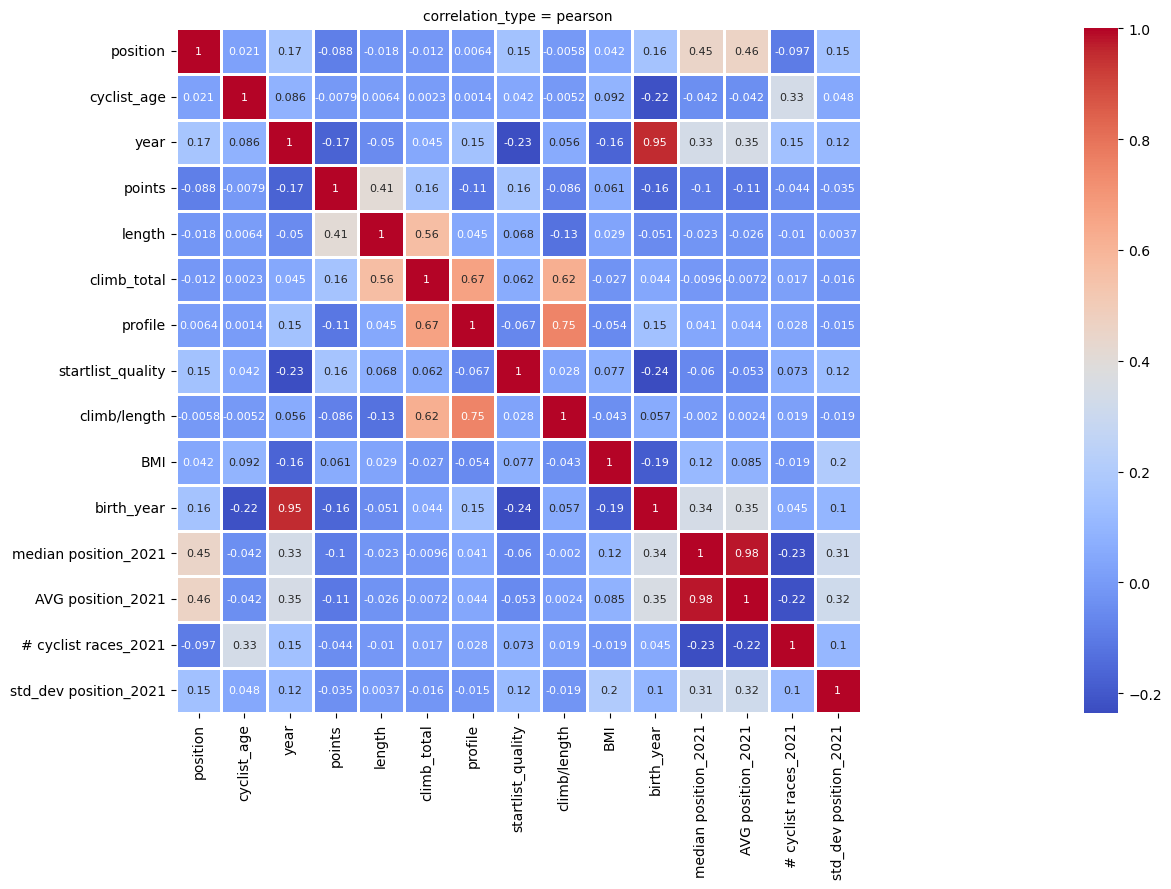

In [38]:
show_heatmap(dataset, dataset.columns, 'pearson')

In [39]:
dataset.rename(columns={'year': 'race_year'}, inplace=True)
dataset.drop(['birth_year'], axis=1, inplace=True) #birth_year is redundant w.r.t race_year
dataset.drop(['median position_2021'], axis=1, inplace=True) 
# climb/lenght is redundant
# cyclist and url are identifiers
dataset.drop(['climb/length', 'cyclist', '_url'], axis=1, inplace=True)

#column rendundant w.r.t geo area
dataset.drop(['nationality', 'continent'], axis=1, inplace=True)

We decide to keep the 'geo area' because it has a reasonable amount of values so, if we need to use the one hot encoding, we do not generate too many artificial columns. 


In [40]:
dataset.head()

,position,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,geo area,AVG position_2021,# cyclist races_2021,std_dev position_2021
0,0,24,1970,225,240000,2611,2,372,22.057578,Western Europe,13.0,37.0,18.685480
1,1,26,1970,225,240000,2611,2,372,18.646937,Western Europe,10.0,10.0,8.141116
2,2,23,1970,225,240000,2611,2,372,22.840000,Western Europe,16.0,67.0,18.234961
3,3,24,1970,225,240000,2611,2,372,21.748939,Western Europe,7.0,38.0,7.836705
4,4,23,1970,225,240000,2611,2,372,22.727257,Western Europe,20.0,7.0,9.860938


Let's generate the *class binary label* TOP20, which takes 1 as value if the position of the placement is in the range [0, 19], 0 otherwise.

In [41]:
dataset['top20'] = (dataset['position'] < 20).astype(int)

In [42]:
dataset[['top20', 'position']]

,top20,position
0,1,0
1,1,1
2,1,2
3,1,3
4,1,4
...,...,...
509059,0,98
509060,0,99
509061,0,100
509062,0,101


'Position' must be removed as it directly defines the top20 label.

In [43]:
dataset.drop(['position'], axis=1, inplace=True)

In [44]:
dataset.columns

Index(['cyclist_age', 'race_year', 'points', 'length', 'climb_total',
       'profile', 'startlist_quality', 'BMI', 'geo area', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021', 'top20'],
      dtype='object')

### Feature encoding for non distance method

In [45]:
#input: the dataset and the list of variables' names to encode
def categorical_columns_encoding(dataset, variables):
    dataset = dataset.copy()
    for variable in variables:
        #get the unique variable's values
        var = sorted(dataset[variable].unique())
        
        #generate a mapping from the variable's values to the number representation  
        mapping = dict(zip(var, range(0, len(var) + 1)))

        print(f"Mapping of {variable}:", mapping)
        #add a new colum with the number representation of the variable
        dataset[variable+'_num'] = dataset[variable].map(mapping).astype(int)
    return dataset

In [46]:
categorical_columns = ['geo area']
dataset_for_non_distance = categorical_columns_encoding(dataset, categorical_columns)

Mapping of geo area: {'Africa': 0, 'America': 1, 'Asia': 2, 'Eastern Europe': 3, 'Northern Europe': 4, 'Oceania': 5, 'Southern Europe': 6, 'Western Europe': 7}


### Feature encoding for distance method

In the classifiers that exploit the notion of distance, it's important to apply a preliminary normalization step so that we reduce the bias given by the range of the different attributes. In this case we use a standardization (z-score normalization). Let's retrieve the original dataset that we have to standardize and let's apply the one hot encoding to the geo area column.

In [47]:
dataset_for_distance = dataset.copy()
dataset_for_distance.head()

,cyclist_age,race_year,points,length,climb_total,profile,startlist_quality,BMI,geo area,AVG position_2021,# cyclist races_2021,std_dev position_2021,top20
0,24,1970,225,240000,2611,2,372,22.057578,Western Europe,13.0,37.0,18.685480,1
1,26,1970,225,240000,2611,2,372,18.646937,Western Europe,10.0,10.0,8.141116,1
2,23,1970,225,240000,2611,2,372,22.840000,Western Europe,16.0,67.0,18.234961,1
3,24,1970,225,240000,2611,2,372,21.748939,Western Europe,7.0,38.0,7.836705,1
4,23,1970,225,240000,2611,2,372,22.727257,Western Europe,20.0,7.0,9.860938,1


In [48]:
# Remove the profile column which is an ordinal
dataset_for_distance.drop(['profile'], axis=1, inplace=True)

In [49]:
dataset_for_distance.columns

Index(['cyclist_age', 'race_year', 'points', 'length', 'climb_total',
       'startlist_quality', 'BMI', 'geo area', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021', 'top20'],
      dtype='object')

In [50]:
dataset_for_distance.columns

Index(['cyclist_age', 'race_year', 'points', 'length', 'climb_total',
       'startlist_quality', 'BMI', 'geo area', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021', 'top20'],
      dtype='object')

In [51]:
scaler = StandardScaler()
columns_to_be_scaled = ['cyclist_age', 'race_year', 'points', 'length', 'climb_total',
       'startlist_quality', 'BMI', 'AVG position_2021',
       '# cyclist races_2021', 'std_dev position_2021']
top20 = dataset_for_distance.pop('top20')
geo_area = dataset_for_distance.pop('geo area')
dataset_for_distance = pd.DataFrame(scaler.fit_transform(dataset_for_distance), columns=columns_to_be_scaled)
dataset_for_distance = pd.concat([dataset_for_distance.reset_index(drop=True), top20.reset_index(drop=True)], axis=1)
dataset_for_distance = pd.concat([dataset_for_distance.reset_index(drop=True), geo_area.reset_index(drop=True)], axis=1)

In [52]:
dataset_for_distance

,cyclist_age,race_year,points,length,climb_total,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,top20,geo area
0,-1.141184,-2.988317,2.457905,1.126943,0.248058,-1.884112,0.663382,-2.757590,-1.388444,-2.716432,1,Western Europe
1,-0.593687,-2.988317,2.457905,1.126943,0.248058,-1.884112,-1.940399,-2.888813,-1.574537,-3.927118,1,Western Europe
2,-1.414933,-2.988317,2.457905,1.126943,0.248058,-1.884112,1.260706,-2.626367,-1.181674,-2.768160,1,Western Europe
3,-1.141184,-2.988317,2.457905,1.126943,0.248058,-1.884112,0.427759,-3.020037,-1.381551,-3.962070,1,Western Europe
4,-1.414933,-2.988317,2.457905,1.126943,0.248058,-1.884112,1.174634,-2.451402,-1.595214,-3.729651,1,Western Europe
...,...,...,...,...,...,...,...,...,...,...,...,...
509059,-1.414933,1.388813,4.730063,1.543880,1.432754,-0.118391,-0.327226,NaN,NaN,NaN,0,Western Europe
509060,-1.414933,1.388813,4.730063,1.543880,1.432754,-0.118391,-1.166998,NaN,NaN,NaN,0,Northern Europe
509061,-0.867436,1.388813,4.730063,1.543880,1.432754,-0.118391,-1.052483,-0.832981,-0.857734,-0.159066,0,Western Europe
509062,-1.414933,1.388813,4.730063,1.543880,1.432754,-0.118391,-0.449375,-0.351829,-1.533183,-0.498829,0,Northern Europe


In [53]:
dataset_for_distance = pd.get_dummies(dataset_for_distance, columns = ['geo area'], prefix_sep='_') #One hot encoding

In [54]:
dataset_for_distance.head()

,cyclist_age,race_year,points,length,climb_total,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,top20,geo area_Africa,geo area_America,geo area_Asia,geo area_Eastern Europe,geo area_Northern Europe,geo area_Oceania,geo area_Southern Europe,geo area_Western Europe
0,-1.141184,-2.988317,2.457905,1.126943,0.248058,-1.884112,0.663382,-2.757590,-1.388444,-2.716432,1,False,False,False,False,False,False,False,True
1,-0.593687,-2.988317,2.457905,1.126943,0.248058,-1.884112,-1.940399,-2.888813,-1.574537,-3.927118,1,False,False,False,False,False,False,False,True
2,-1.414933,-2.988317,2.457905,1.126943,0.248058,-1.884112,1.260706,-2.626367,-1.181674,-2.768160,1,False,False,False,False,False,False,False,True
3,-1.141184,-2.988317,2.457905,1.126943,0.248058,-1.884112,0.427759,-3.020037,-1.381551,-3.962070,1,False,False,False,False,False,False,False,True
4,-1.414933,-2.988317,2.457905,1.126943,0.248058,-1.884112,1.174634,-2.451402,-1.595214,-3.729651,1,False,False,False,False,False,False,False,True


In [55]:
dataset.drop(categorical_columns, axis=1, inplace=True) #column already encoded

## Data segmentation: (Train - Test)

In [56]:
original_size=dataset_for_non_distance.shape[0]

# Original dataset
test_set=dataset_for_non_distance[dataset_for_non_distance['race_year']>=2022]
train_set=dataset_for_non_distance[dataset_for_non_distance['race_year']<2022]
print(f"[Original] Training set size: {train_set.shape[0]} ({train_set.shape[0] * 100 / original_size:.2f}%)")
print(f"[Original] Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")

# Standardized dataset
# the year '2022' has been standardized hence we need this transformation to extract the test set
mean = dataset_for_non_distance['race_year'].describe()['mean']
std = dataset_for_non_distance['race_year'].describe()['std']
threshold_for_standardized = (2022-mean)/std 
test_set_std=dataset_for_distance[dataset_for_distance['race_year']>=threshold_for_standardized]
train_set_std=dataset_for_distance[dataset_for_distance['race_year']<threshold_for_standardized]
print(f"[Standard.] Training set size: {test_set_std.shape[0]} ({test_set_std.shape[0] * 100 / original_size:.2f}%)")
print(f"[Standard.] Test set size: {train_set_std.shape[0]} ({train_set_std.shape[0] * 100 / original_size:.2f}%)")

[Original] Training set size: 476478 (93.60%)
[Original] Test set size: 32586 (6.40%)
[Standard.] Training set size: 32586 (6.40%)
[Standard.] Test set size: 476478 (93.60%)


In [57]:
test_top20_counts = test_set['top20'].value_counts(normalize=True)
train_top20_counts = train_set['top20'].value_counts(normalize=True)

results = pd.DataFrame({
    'Test Set': test_top20_counts,
    'Training Set': train_top20_counts
})
print("Class distribution in train/test set")
print(results)

Class distribution in train/test set
       Test Set  Training Set
top20                        
0       0.86129      0.844591
1       0.13871      0.155409


In [58]:
# Label extraction
train_label=train_set.pop('top20') 
test_label=test_set.pop('top20') #labels for the test set

# Same labels are valid also for the standardized dataset
train_set_std.drop(['top20'], axis=1, inplace=True) 
test_set_std.drop(['top20'], axis=1, inplace=True)

C:\Users\simon\AppData\Local\Temp\ipykernel_11476\1430941208.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_set_std.drop(['top20'], axis=1, inplace=True)
C:\Users\simon\AppData\Local\Temp\ipykernel_11476\1430941208.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_set_std.drop(['top20'], axis=1, inplace=True)


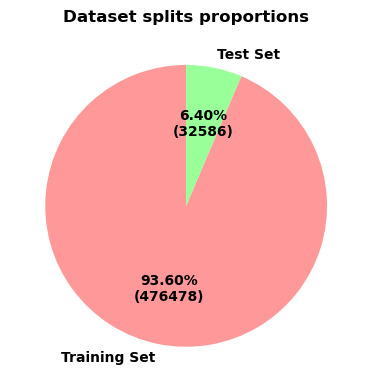

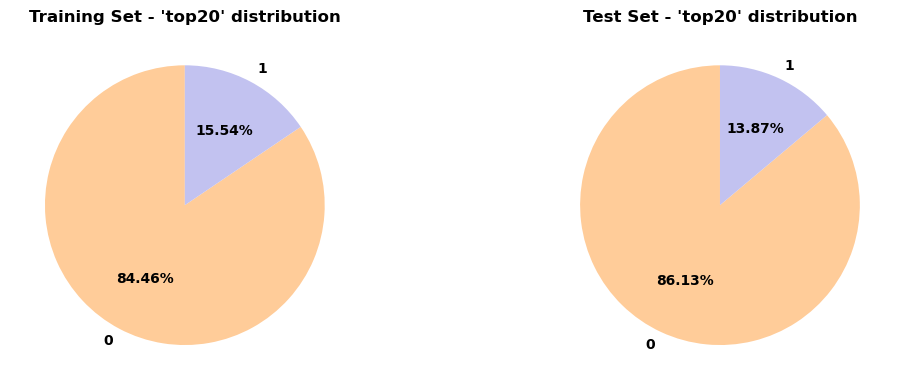

In [60]:
#Set sizes
train_size = train_set.shape[0]
test_size = test_set.shape[0]
original_size = train_size + test_size

# Pie plot for the set sizes
set_sizes = [train_size, test_size]
set_labels = ["Training Set", "Test Set"]
set_colors = ["#ff9999", "#99ff99"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(
    set_sizes,
    labels=set_labels,
    autopct=lambda p: f'{p:.2f}%\n({p*original_size/100:.0f})',
    startangle=90,
    colors=set_colors,
    textprops={'fontweight': 'bold'}
)
plt.title("Dataset splits proportions", fontweight='bold')

# Pie plot for the class distribution in the 3 partitions 
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

distributions = [train_top20_counts, test_top20_counts]
titles = ["Training Set", "Test Set"]
colors = [["#ffcc99", "#c2c2f0"], ["#ffcc99", "#c2c2f0"]]

for ax, data, title, color in zip(axes, distributions, titles, colors):
    ax.pie(
        data,
        labels=data.index,
        autopct='%1.2f%%',
        startangle=90,
        colors=color,
        textprops={'fontweight': 'bold'}
    )
    ax.set_title(f"{title} - 'top20' distribution", fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

### Undersampling
Under-sample the majority class by randomly picking samples with or without replacement. Notice that this strategy can exclude relevant data from the majority class.

In [61]:
# sampling_strategy --> if float, it is the desired ratio of the # of samples in the minority class over the # of 
#   samples in the majority class after resampling.
rand_undersampler=RandomUnderSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)

#Let's balance the classes with the proportion 0:60% - 1:40% (vs 87%-13% in the initial setting)
#40/60=0.67

In [62]:
# The undersampling is done only on the training data
train_set_us, train_label_us = rand_undersampler.fit_resample(train_set, train_label)

top20
0    0.5988
1    0.4012
Name: proportion, dtype: float64


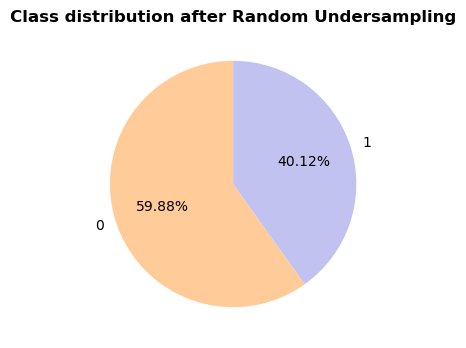

Initial training set size 476478. After undersampling 184569


In [63]:
class_distribution = train_label_us.value_counts(normalize=True)
print(class_distribution)
plt.figure(figsize=(4, 4))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.2f%%', startangle=90, colors=["#ffcc99", "#c2c2f0"])
plt.title("Class distribution after Random Undersampling", fontweight='bold')
plt.show()
plt.close()
print(f"Initial training set size {train_label.shape[0]}. After undersampling {train_label_us.shape[0]}")

In fact, this strategy drastically reduced the amount of data available to train the model.

In [64]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(train_set[column], train_set_us[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: cyclist_age, KS statistic: 0.0094, P-value: 0.0000
Column: race_year, KS statistic: 0.0485, P-value: 0.0000
Column: points, KS statistic: 0.0143, P-value: 0.0000
Column: length, KS statistic: 0.0091, P-value: 0.0000
Column: climb_total, KS statistic: 0.0092, P-value: 0.0000
Column: profile, KS statistic: 0.0100, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0353, P-value: 0.0000
Column: BMI, KS statistic: 0.0123, P-value: 0.0000
Column: geo area, KS statistic: 0.0048, P-value: 0.0045
Column: AVG position_2021, KS statistic: 0.0782, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0132, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0211, P-value: 0.0000
Column: geo area_num, KS statistic: 0.0048, P-value: 0.0045


In a previous iteration we have observed that the proportion 70:30 had an higher impact on the distribution. Also in this setting the distribution of some variables have been influenced. 

In [64]:
# from imblearn.under_sampling import RandomUnderSampler
# from imblearn.under_sampling import CondensedNearestNeighbour
# from imblearn.under_sampling import ClusterCentroids

# import pandas
# import numpy
# from sklearn.cluster import KMeans


# models = [
#     RandomUnderSampler(random_state=RANDOM_STATE),
#     #CondensedNearestNeighbour(random_state=RANDOM_STATE),
#     ClusterCentroids(
#     estimator=KMeans(n_clusters=3, max_iter=15, n_init=1, random_state=RANDOM_STATE))
# ]
# undersampling_algorithms = [
#     "random",
#     #"condensed_rule",
#     "centroids"
# ]
# undersampled_datasets = list()

# for algorithm, model in zip(undersampling_algorithms, models):
#     print(algorithm)
#     undersampled_data, undersampled_labels = model.fit_resample(train_set_std, train_label)
#     undersampled_dataset = pandas.DataFrame(undersampled_data, undersampled_labels)
#     undersampled_dataset["algorithm"] = algorithm
#     undersampled_datasets.append(undersampled_dataset)

### Oversampling
Over-sample the minority class by picking samples at random with replacement.

#### Random oversampling

In [65]:
# sampling_strategy --> if float, it is the desired ratio of the # of samples in the minority class over the # of 
#   samples in the majority class after resampling.
rand_oversampler=RandomOverSampler(random_state=RANDOM_STATE, sampling_strategy=0.67)

#Let's balance the classes with the proportion 0:60% - 1:40% (vs 87%-13% in the initial setting)
#40/60=0.67

In [66]:
# The oversampling is done only on the training data
train_set_os, train_label_os = rand_oversampler.fit_resample(train_set, train_label)

top20
0    0.598803
1    0.401197
Name: proportion, dtype: float64


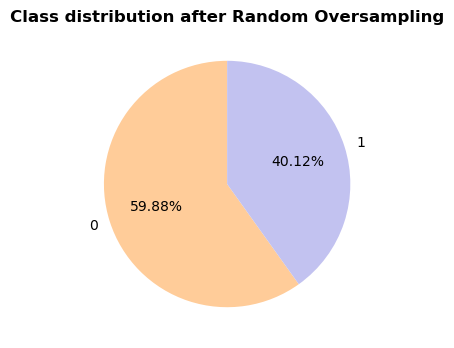

Initial training set size 476478. After oversampling 672056


In [67]:
class_distribution = train_label_os.value_counts(normalize=True)
print(class_distribution)
plt.figure(figsize=(4, 4))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.2f%%', startangle=90, colors=["#ffcc99", "#c2c2f0"])
plt.title("Class distribution after Random Oversampling", fontweight='bold')
plt.show()
plt.close()
print(f"Initial training set size {train_label.shape[0]}. After oversampling {train_label_os.shape[0]}")

In this case the number of training samples is increased, since some instances of the minority class have been duplicated.

In [68]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(train_set[column], train_set_os[column], alternative="two-sided"))
    for column in train_set.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: cyclist_age, KS statistic: 0.0109, P-value: 0.0000
Column: race_year, KS statistic: 0.0486, P-value: 0.0000
Column: points, KS statistic: 0.0149, P-value: 0.0000
Column: length, KS statistic: 0.0086, P-value: 0.0000
Column: climb_total, KS statistic: 0.0088, P-value: 0.0000
Column: profile, KS statistic: 0.0100, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0352, P-value: 0.0000
Column: BMI, KS statistic: 0.0143, P-value: 0.0000
Column: geo area, KS statistic: 0.0061, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0774, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0130, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0218, P-value: 0.0000
Column: geo area_num, KS statistic: 0.0061, P-value: 0.0000


#### SMOTE: Synthetic Minority Oversampling Technique
The Synthetic Minority Over-Sampling Technique (SMOTE) is a used to handle class imbalance in datasets. SMOTE handles this issue by generating samples of minority classes to make the class distribution balanced. The algorithm uses an approach based on the K-NN classifier. So we need to perform the proper preprocessing.

In [69]:
smote_oversampler = SMOTE(k_neighbors=5, sampling_strategy=0.67, random_state=RANDOM_STATE)

In [70]:
train_set_smote, train_label_smote = smote_oversampler.fit_resample(train_set_std, train_label)

top20
0    0.598803
1    0.401197
Name: proportion, dtype: float64


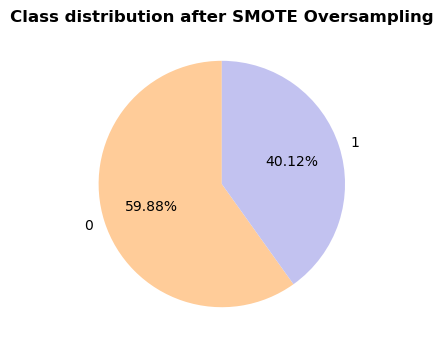

Initial training set size 476478. After undersampling 672056


In [71]:
class_distribution = train_label_smote.value_counts(normalize=True)
print(class_distribution)
plt.figure(figsize=(4, 4))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.2f%%', startangle=90, colors=["#ffcc99", "#c2c2f0"])
plt.title("Class distribution after SMOTE Oversampling", fontweight='bold')
plt.show()
plt.close()
print(f"Initial training set size {train_label.shape[0]}. After undersampling {train_label_smote.shape[0]}")

In [72]:
# KS Test on all the columns
test_results = [
    (column, ks_2samp(train_set_std[column], train_set_smote[column], alternative="two-sided"))
    for column in train_set_std.columns
]
for column, result in test_results:
    print(f"Column: {column}, KS statistic: {result.statistic:.4f}, P-value: {result.pvalue:.4f}")

Column: cyclist_age, KS statistic: 0.0203, P-value: 0.0000
Column: race_year, KS statistic: 0.0507, P-value: 0.0000
Column: points, KS statistic: 0.0285, P-value: 0.0000
Column: length, KS statistic: 0.0082, P-value: 0.0000
Column: climb_total, KS statistic: 0.0086, P-value: 0.0000
Column: startlist_quality, KS statistic: 0.0350, P-value: 0.0000
Column: BMI, KS statistic: 0.0150, P-value: 0.0000
Column: AVG position_2021, KS statistic: 0.0792, P-value: 0.0000
Column: # cyclist races_2021, KS statistic: 0.0123, P-value: 0.0000
Column: std_dev position_2021, KS statistic: 0.0218, P-value: 0.0000
Column: geo area_Africa, KS statistic: 0.0010, P-value: 0.9427
Column: geo area_America, KS statistic: 0.0008, P-value: 0.9954
Column: geo area_Asia, KS statistic: 0.0013, P-value: 0.7757
Column: geo area_Eastern Europe, KS statistic: 0.0021, P-value: 0.1542
Column: geo area_Northern Europe, KS statistic: 0.0016, P-value: 0.4646
Column: geo area_Oceania, KS statistic: 0.0007, P-value: 0.9995
Colu

In [73]:
display(train_set_std)

,cyclist_age,race_year,points,length,climb_total,startlist_quality,BMI,AVG position_2021,# cyclist races_2021,std_dev position_2021,geo area_Africa,geo area_America,geo area_Asia,geo area_Eastern Europe,geo area_Northern Europe,geo area_Oceania,geo area_Southern Europe,geo area_Western Europe
0,-1.141184,-2.988317,2.457905,1.126943,0.248058,-1.884112,0.663382,-2.757590,-1.388444,-2.716432,False,False,False,False,False,False,False,True
1,-0.593687,-2.988317,2.457905,1.126943,0.248058,-1.884112,-1.940399,-2.888813,-1.574537,-3.927118,False,False,False,False,False,False,False,True
2,-1.414933,-2.988317,2.457905,1.126943,0.248058,-1.884112,1.260706,-2.626367,-1.181674,-2.768160,False,False,False,False,False,False,False,True
3,-1.141184,-2.988317,2.457905,1.126943,0.248058,-1.884112,0.427759,-3.020037,-1.381551,-3.962070,False,False,False,False,False,False,False,True
4,-1.414933,-2.988317,2.457905,1.126943,0.248058,-1.884112,1.174634,-2.451402,-1.595214,-3.729651,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508962,0.775057,1.304638,4.730063,1.565579,-0.026798,0.673587,-0.563889,-1.357875,0.927381,-0.609973,False,True,False,False,False,False,False,False
508963,-0.319938,1.304638,4.730063,1.565579,-0.026798,0.673587,-0.273786,1.835226,-1.416013,0.586267,False,True,False,False,False,False,False,False
508964,-1.141184,1.304638,4.730063,1.565579,-0.026798,0.673587,-0.563889,-0.001900,-1.388444,-1.100136,False,False,False,False,False,False,False,True
508965,0.501308,1.304638,4.730063,1.565579,-0.026798,0.673587,0.741574,0.522993,0.720611,0.979698,False,False,False,False,False,False,False,True


# Data segmentation: (Train - Validation)

The test set should never be used to perform the hyperparameter tuning and the model selection. Since we have a good number of training data, we decide to extract from it a specific _validation set_. In particular we perform a stratified train/test split in order to preserve the initial proportion between the two classes.

In [74]:
# Extraction of the validation set (30% of the training data)
train_set_splitted, validation_set, train_label_splitted, validation_label = train_test_split(train_set, train_label, stratify = train_label, test_size=0.30, random_state=RANDOM_STATE)
training_top20_counts = train_label_splitted.value_counts(normalize=True)
validation_top20_counts = validation_label.value_counts(normalize=True)

results = pd.DataFrame({
    'Training Set': training_top20_counts,
    'Validation Set': validation_top20_counts,
    'Test Set': test_top20_counts
})
print(results)

print(f"Training set size: {train_set_splitted.shape[0]} ({train_set_splitted.shape[0] * 100 / original_size:.2f}%)")
print(f"Validation set size: {validation_set.shape[0]} ({validation_set.shape[0] * 100 / original_size:.2f}%)")
print(f"Test set size: {test_set.shape[0]} ({test_set.shape[0] * 100 / original_size:.2f}%)")

       Training Set  Validation Set  Test Set
top20                                        
0          0.844592        0.844589   0.86129
1          0.155408        0.155411   0.13871
Training set size: 333534 (65.52%)
Validation set size: 142944 (28.08%)
Test set size: 32586 (6.40%)


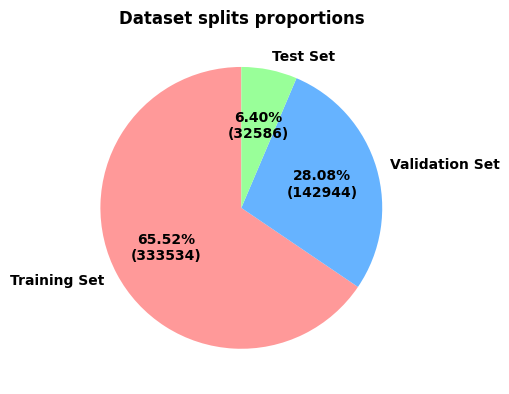

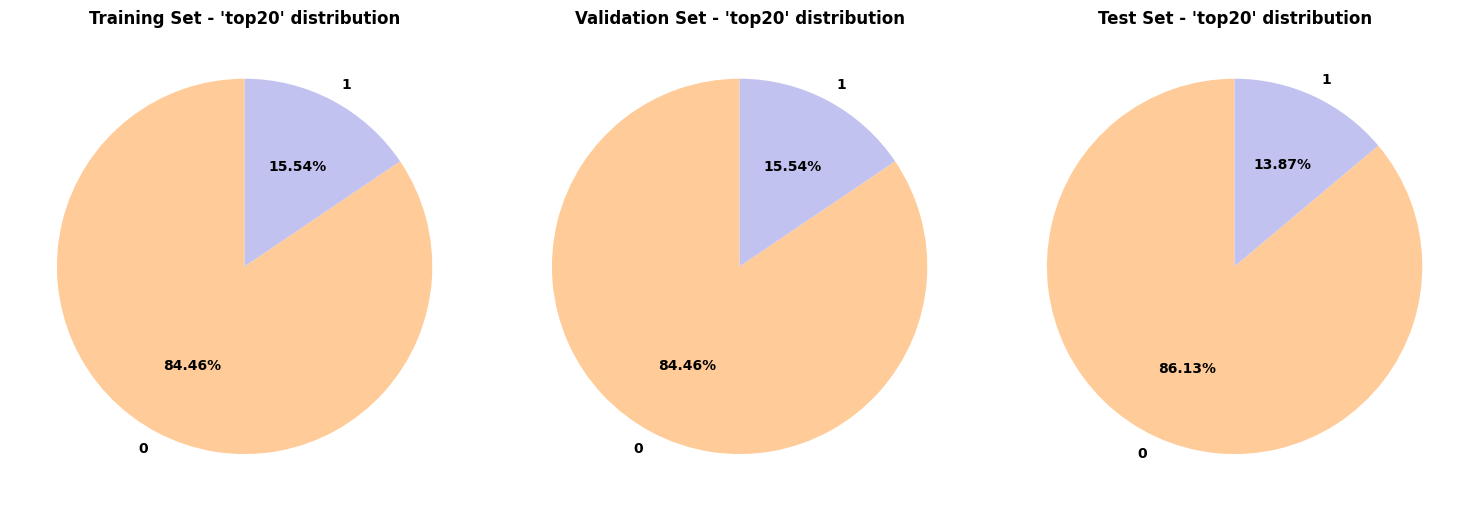

In [75]:
#Set sizes
train_size = train_set_splitted.shape[0]
validation_size = validation_set.shape[0]
test_size = test_set.shape[0]
original_size = train_size + validation_size + test_size

# Pie plot for the set sizes
set_sizes = [train_size, validation_size, test_size]
set_labels = ["Training Set", "Validation Set", "Test Set"]
set_colors = ["#ff9999", "#66b3ff", "#99ff99"]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.pie(
    set_sizes,
    labels=set_labels,
    autopct=lambda p: f'{p:.2f}%\n({p*original_size/100:.0f})',
    startangle=90,
    colors=set_colors,
    textprops={'fontweight': 'bold'}
)
plt.title("Dataset splits proportions", fontweight='bold')

# Pie plot for the class distribution in the 3 partitions 
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

distributions = [training_top20_counts, validation_top20_counts, test_top20_counts]
titles = ["Training Set", "Validation Set", "Test Set"]
colors = [["#ffcc99", "#c2c2f0"], ["#ffcc99", "#c2c2f0"], ["#ffcc99", "#c2c2f0"]]

for ax, data, title, color in zip(axes, distributions, titles, colors):
    ax.pie(
        data,
        labels=data.index,
        autopct='%1.2f%%',
        startangle=90,
        colors=color,
        textprops={'fontweight': 'bold'}
    )
    ax.set_title(f"{title} - 'top20' distribution", fontweight='bold')

plt.tight_layout()
plt.show()
plt.close()

The visualization confirms that we are in an "unbalanced" context, with a minority '1' class.

In [76]:
train_set.isna().sum()

cyclist_age              0
race_year                0
points                   0
length                   0
climb_total              0
profile                  0
startlist_quality        0
BMI                      0
geo area                 0
AVG position_2021        0
# cyclist races_2021     0
std_dev position_2021    0
geo area_num             0
dtype: int64

In [77]:
validation_set.isna().sum()

cyclist_age              0
race_year                0
points                   0
length                   0
climb_total              0
profile                  0
startlist_quality        0
BMI                      0
geo area                 0
AVG position_2021        0
# cyclist races_2021     0
std_dev position_2021    0
geo area_num             0
dtype: int64

In [78]:
test_set.isna().sum()

cyclist_age                 0
race_year                   0
points                      0
length                      0
climb_total                 0
profile                     0
startlist_quality           0
BMI                         0
geo area                    0
AVG position_2021        3569
# cyclist races_2021     3569
std_dev position_2021    3569
geo area_num                0
dtype: int64

Only the test set have some records with NaNs, for the reasons described above. Notice that there are 3569 with NaN statistics over 32586 total test set rows (about 10%).

For the usage of the grid search exploiting the **Cross Validation** technique, we need to use both training and validation data. In fact the validation set is repeatedly selected among all the training data. For this reason the classification_utility file provides the functions for retrieving the whole training dataset or the splitted version (with a validation set). <br>
Moreover the splitting in train-validation can also be performed on the training data corrected using some undersampling/oversampling technique. The procedure is the same presented above. In the utility file there are proper procedures to do that.